# Collapse Strain Energy — Geometry-Aware Stiffness Cost

This notebook develops the idea that **elastic strain energy induced by an edge collapse**
is a natural geometry-aware cost metric that unifies geometric fidelity and mechanical importance.

Key insight: when we collapse an edge, the surrounding triangles change shape (edge lengths change,
dihedral angles change). The stiffness matrix tells us exactly how costly these changes are:
- **Membrane strain energy** penalizes edge length changes (metric distortion)
- **Bending strain energy** penalizes dihedral angle changes (curvature distortion)

Together they give a single scalar cost that is:
1. Geometry-aware (penalizes vertex drift through strain)
2. Material-weighted (stiff regions are more expensive to distort)
3. Position-dependent (can optimize where to place the merged vertex)
4. Self-contained (no separate QEM needed)

**Toy mesh:** A non-planar "tent" shape — 5 vertices with a raised center — so that
dihedral angles are nonzero and bending energy matters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The Toy Mesh: A Tent

5 vertices, 4 triangles. Vertex 0 is raised above the plane to create non-zero dihedral angles.

```
        2
       /|\
      / | \
     /  |  \
    3---0---1
     \  |  /
      \ | /
       \|/
        4
```

- v0 = (0, 0, 0.5) — raised center
- v1 = (1, 0, 0) — right
- v2 = (0, 1, 0) — top
- v3 = (-1, 0, 0) — left
- v4 = (0, -1, 0) — bottom

We'll collapse edge **(0, 1)** — pulling the center toward the right.

In [2]:
from kms.mesh import TriMesh

vertices = np.array([
    [0.0,  0.0, 0.5],   # v0: raised center
    [1.0,  0.0, 0.0],   # v1: right
    [0.0,  1.0, 0.0],   # v2: top
    [-1.0, 0.0, 0.0],   # v3: left
    [0.0, -1.0, 0.0],   # v4: bottom
], dtype=np.float64)

faces = np.array([
    [0, 1, 2],  # f0: center-right-top
    [0, 2, 3],  # f1: center-top-left
    [0, 3, 4],  # f2: center-left-bottom
    [0, 4, 1],  # f3: center-bottom-right
], dtype=np.int64)

mesh = TriMesh(vertices=vertices, faces=faces)
print(f"Mesh: {mesh.n_verts} verts, {mesh.n_faces} faces")
print(f"\nVertices:")
for i, v in enumerate(vertices):
    print(f"  v{i}: ({v[0]:5.2f}, {v[1]:5.2f}, {v[2]:5.2f})")
print(f"\nFaces:")
for i, f in enumerate(faces):
    print(f"  f{i}: [{f[0]}, {f[1]}, {f[2]}]")

Mesh: 5 verts, 4 faces

Vertices:
  v0: ( 0.00,  0.00,  0.50)
  v1: ( 1.00,  0.00,  0.00)
  v2: ( 0.00,  1.00,  0.00)
  v3: (-1.00,  0.00,  0.00)
  v4: ( 0.00, -1.00,  0.00)

Faces:
  f0: [0, 1, 2]
  f1: [0, 2, 3]
  f2: [0, 3, 4]
  f3: [0, 4, 1]


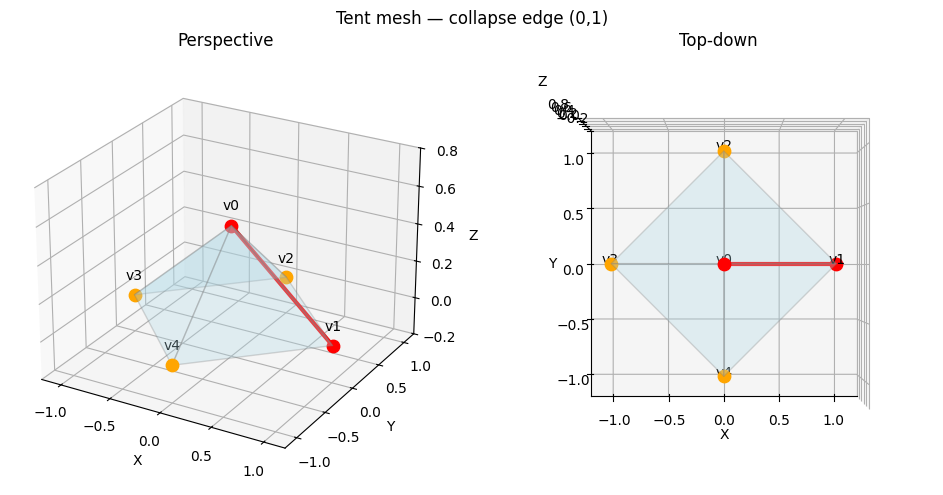

In [3]:
fig = plt.figure(figsize=(10, 5))

for subplot_idx, (elev, azim, title) in enumerate([(25, -60, 'Perspective'), (90, -90, 'Top-down')]):
    ax = fig.add_subplot(1, 2, subplot_idx + 1, projection='3d')
    
    # Draw triangles
    tri_verts = [[vertices[f] for f in face] for face in faces]
    poly = Poly3DCollection(tri_verts, alpha=0.3, facecolor='lightblue', edgecolor='gray', linewidth=1)
    ax.add_collection3d(poly)
    
    # Highlight edge (0, 1)
    ax.plot(*zip(vertices[0], vertices[1]), 'r-', linewidth=3, label='edge (0,1)')
    
    # Draw vertices
    colors_v = ['red', 'red', 'orange', 'orange', 'orange']
    for i, (v, c) in enumerate(zip(vertices, colors_v)):
        ax.scatter(*v, color=c, s=80, zorder=5)
        ax.text(v[0], v[1], v[2] + 0.08, f'v{i}', fontsize=10, ha='center')
    
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-0.2, 0.8)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)

plt.suptitle('Tent mesh — collapse edge (0,1)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Pre-Collapse Geometry: Edge Lengths & Dihedral Angles

Before we can measure "how much the geometry changed," we need the original state:
- **Edge lengths** — the discrete metric (first fundamental form)
- **Dihedral angles** — the discrete curvature (second fundamental form)

These two fully characterize the surface geometry in the discrete sense.

In [4]:
from kms.adjacency import MeshAdjacency

adj = MeshAdjacency(mesh)
edges = adj.get_edges()

print("Edge lengths (original):")
edge_lengths_orig = {}
for u, v in edges:
    length = np.linalg.norm(vertices[u] - vertices[v])
    edge_lengths_orig[(u, v)] = length
    print(f"  ({u},{v}): {length:.6f}")

Edge lengths (original):
  (0,1): 1.118034
  (0,2): 1.118034
  (0,3): 1.118034
  (0,4): 1.118034
  (1,2): 1.414214
  (1,4): 1.414214
  (2,3): 1.414214
  (3,4): 1.414214


In [5]:
def compute_dihedral_angle(v0, v1, v_opp_a, v_opp_b):
    """Dihedral angle at edge (v0, v1) between its two adjacent triangles.
    
    v_opp_a and v_opp_b are the opposite vertices in the two triangles.
    Returns angle in radians (0 = flat, pi = fully folded).
    """
    e = v1 - v0
    # Normals of the two faces
    n_a = np.cross(e, v_opp_a - v0)
    n_b = np.cross(e, v_opp_b - v0)
    n_a = n_a / np.linalg.norm(n_a)
    n_b = n_b / np.linalg.norm(n_b)
    # Dihedral = pi - angle between normals
    cos_angle = np.clip(np.dot(n_a, n_b), -1, 1)
    return np.arccos(cos_angle)


# Find interior edges (shared by 2 faces) and their opposite vertices
print("Dihedral angles at interior edges (original):")
print("  (0 = flat, pi = fully folded)\n")

dihedral_orig = {}
for (u, v), face_set in adj.edge_faces.items():
    if len(face_set) != 2:
        continue
    fi_a, fi_b = list(face_set)
    # Find opposite vertices
    face_a = set(adj.faces[fi_a].tolist())
    face_b = set(adj.faces[fi_b].tolist())
    opp_a = (face_a - {u, v}).pop()
    opp_b = (face_b - {u, v}).pop()
    
    angle = compute_dihedral_angle(vertices[u], vertices[v], vertices[opp_a], vertices[opp_b])
    dihedral_orig[(u, v)] = angle
    print(f"  edge ({u},{v}): {angle:.4f} rad = {np.degrees(angle):.2f}°  (opp: v{opp_a}, v{opp_b})")

Dihedral angles at interior edges (original):
  (0 = flat, pi = fully folded)

  edge (0,1): 2.3005 rad = 131.81°  (opp: v2, v4)
  edge (0,2): 2.3005 rad = 131.81°  (opp: v1, v3)
  edge (0,3): 2.3005 rad = 131.81°  (opp: v2, v4)
  edge (0,4): 2.3005 rad = 131.81°  (opp: v3, v1)


## 3. After Collapse: New Geometry

Collapse edge (0, 1) → merged vertex w at position p_w = (1-α)·v0 + α·v1.

What changes:
- Faces f0 (0,1,2) and f3 (0,4,1) are **deleted** (they shared edge (0,1))
- Surviving faces f1 (0,2,3) and f2 (0,3,4) now have vertex 0 at p_w
- Edge lengths from v0 to v2, v3, v4 all change
- Dihedral angles at surviving edges change

Let's compute the geometry at α = 0.5 (midpoint).

In [6]:
alpha = 0.5
p_w = (1 - alpha) * vertices[0] + alpha * vertices[1]
print(f"Collapse (0,1) at alpha={alpha}")
print(f"  v0 was at: {vertices[0]}")
print(f"  v1 was at: {vertices[1]}")
print(f"  p_w:       {p_w}")
print()

# After collapse: vertex 0 moves to p_w, vertex 1 is eliminated
# Surviving faces: f1 (0,2,3) and f2 (0,3,4), with v0 at p_w
# Deleted faces: f0 (0,1,2) and f3 (0,4,1)

verts_after = vertices.copy()
verts_after[0] = p_w  # v0 moves to midpoint

surviving_faces = [1, 2]  # f1: (0,2,3), f2: (0,3,4)
surviving_verts = [0, 2, 3, 4]  # v1 eliminated

print("Surviving faces (with v0 at p_w):")
for fi in surviving_faces:
    f = faces[fi]
    print(f"  f{fi}: [{f[0]}, {f[1]}, {f[2]}]  verts: {verts_after[f[0]]}, {verts_after[f[1]]}, {verts_after[f[2]]}")

Collapse (0,1) at alpha=0.5
  v0 was at: [0.  0.  0.5]
  v1 was at: [1. 0. 0.]
  p_w:       [0.5  0.   0.25]

Surviving faces (with v0 at p_w):
  f1: [0, 2, 3]  verts: [0.5  0.   0.25], [0. 1. 0.], [-1.  0.  0.]
  f2: [0, 3, 4]  verts: [0.5  0.   0.25], [-1.  0.  0.], [ 0. -1.  0.]


In [7]:
# Compute edge length changes for affected edges
print("Edge length changes after collapse:")
print(f"  {'Edge':<10s} {'Before':>10s} {'After':>10s} {'Change':>10s} {'Strain':>10s}")
print(f"  {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

# Affected edges: (0,2), (0,3), (0,4) — edges from the merged vertex to its neighbors
affected_edges = [(0, 2), (0, 3), (0, 4)]
edge_strains = {}

for u, v in affected_edges:
    l_before = np.linalg.norm(vertices[u] - vertices[v])
    l_after = np.linalg.norm(verts_after[u] - verts_after[v])
    change = l_after - l_before
    strain = (l_after - l_before) / l_before  # engineering strain
    edge_strains[(u, v)] = strain
    print(f"  ({u},{v})      {l_before:10.6f} {l_after:10.6f} {change:+10.6f} {strain:+10.6f}")

# Edge (2,3) and (3,4) don't change (neither endpoint moved)
for u, v in [(2, 3), (3, 4)]:
    l_before = np.linalg.norm(vertices[u] - vertices[v])
    l_after = np.linalg.norm(verts_after[u] - verts_after[v])
    print(f"  ({u},{v})      {l_before:10.6f} {l_after:10.6f} {'unchanged':>10s} {0.0:+10.6f}")

Edge length changes after collapse:
  Edge           Before      After     Change     Strain
  ---------- ---------- ---------- ---------- ----------
  (0,2)        1.118034   1.145644  +0.027610  +0.024695
  (0,3)        1.118034   1.520691  +0.402657  +0.360147
  (0,4)        1.118034   1.145644  +0.027610  +0.024695
  (2,3)        1.414214   1.414214  unchanged  +0.000000
  (3,4)        1.414214   1.414214  unchanged  +0.000000


In [8]:
# Dihedral angle change at the surviving interior edge (0,3)
# After collapse, edge (0,3) is shared by faces f1:(0,2,3) and f2:(0,3,4)
# Opposite vertices: v2 and v4

angle_before = compute_dihedral_angle(vertices[0], vertices[3], vertices[2], vertices[4])
angle_after = compute_dihedral_angle(verts_after[0], verts_after[3], verts_after[2], verts_after[4])

print("Dihedral angle change at surviving interior edge (0,3):")
print(f"  Before: {angle_before:.6f} rad = {np.degrees(angle_before):.2f}°")
print(f"  After:  {angle_after:.6f} rad = {np.degrees(angle_after):.2f}°")
print(f"  Change: {angle_after - angle_before:+.6f} rad = {np.degrees(angle_after - angle_before):+.2f}°")
print()
print("The dihedral angle changed because v0 moved laterally (toward v1),")
print("breaking the original symmetric tent shape.")

Dihedral angle change at surviving interior edge (0,3):
  Before: 2.300524 rad = 131.81°
  After:  2.815710 rad = 161.33°
  Change: +0.515186 rad = +29.52°

The dihedral angle changed because v0 moved laterally (toward v1),
breaking the original symmetric tent shape.


## 4. Membrane Strain Energy (Metric Distortion)

For each surviving triangle, compute the Green-Lagrange strain from the deformation
of edge lengths, then the strain energy:

$$U_{\text{membrane}} = \sum_{\text{triangles}} \frac{\text{area} \times \text{thickness}}{2} \, \varepsilon^T D \, \varepsilon$$

where:
- ε is the strain tensor (from edge length changes in the triangle)
- D is the constitutive matrix (plane stress, isotropic)

This directly measures **how much the triangle's shape changed** — a purely geometric
quantity weighted by material stiffness.

In [9]:
E_young = 1.0
nu = 0.3
thickness = 0.1  # thick enough that bending matters

# Constitutive matrix (plane stress)
D = (E_young / (1 - nu**2)) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu) / 2],
])

def triangle_membrane_energy(p0_before, p1_before, p2_before, p0_after, p1_after, p2_after):
    """Compute membrane strain energy from triangle deformation.
    
    Uses Green-Lagrange strain in the reference (before) triangle's local frame.
    """
    # Reference triangle: compute local 2D coordinates
    e1_ref = p1_before - p0_before
    e1_len = np.linalg.norm(e1_ref)
    e1_hat = e1_ref / e1_len
    normal = np.cross(e1_ref, p2_before - p0_before)
    area = 0.5 * np.linalg.norm(normal)
    if area < 1e-16:
        return 0.0, np.zeros(3)
    normal_hat = normal / (2 * area)
    e2_hat = np.cross(normal_hat, e1_hat)
    
    # Reference coords (2D)
    # q0 = (0, 0)
    x1_ref = np.dot(p1_before - p0_before, e1_hat)
    x2_ref = np.dot(p2_before - p0_before, e1_hat)
    y2_ref = np.dot(p2_before - p0_before, e2_hat)
    
    # Deformed coords (project deformed positions into reference frame)
    x1_def = np.dot(p1_after - p0_after, e1_hat)
    x2_def = np.dot(p2_after - p0_after, e1_hat)
    y2_def = np.dot(p2_after - p0_after, e2_hat)
    
    # Deformation gradient F (2x2) maps reference to deformed
    # [x1_def, x2_def] = F @ [x1_ref, x2_ref] (for the x-component)
    # Using the CST shape function approach:
    # Reference: nodes at (0,0), (x1_ref, 0), (x2_ref, y2_ref)
    # Deformed: nodes at (0,0), (x1_def, 0), (x2_def, y2_def)
    
    # Jacobian of reference mapping
    J_ref = np.array([[x1_ref, x2_ref], [0, y2_ref]])
    J_def = np.array([[x1_def, x2_def], [0, y2_def]])
    
    if abs(np.linalg.det(J_ref)) < 1e-16:
        return 0.0, np.zeros(3)
    
    # Deformation gradient
    F = J_def @ np.linalg.inv(J_ref)
    
    # Green-Lagrange strain: E = 0.5 * (F^T F - I)
    E_GL = 0.5 * (F.T @ F - np.eye(2))
    
    # Voigt notation: [E11, E22, 2*E12]
    strain_voigt = np.array([E_GL[0, 0], E_GL[1, 1], 2 * E_GL[0, 1]])
    
    # Strain energy
    energy = 0.5 * area * thickness * (strain_voigt @ D @ strain_voigt)
    
    return energy, strain_voigt


print("Membrane strain energy per surviving triangle:\n")
total_membrane = 0.0

for fi in surviving_faces:
    i0, i1, i2 = faces[fi]
    energy, strain = triangle_membrane_energy(
        vertices[i0], vertices[i1], vertices[i2],
        verts_after[i0], verts_after[i1], verts_after[i2],
    )
    total_membrane += energy
    print(f"  f{fi} (v{i0},v{i1},v{i2}):")
    print(f"    strain (Voigt): [{strain[0]:+.6f}, {strain[1]:+.6f}, {strain[2]:+.6f}]")
    print(f"    energy: {energy:.6e}")
    print()

print(f"Total membrane energy: {total_membrane:.6e}")
print("\nThis penalizes edge length changes — the collapse stretched/compressed the triangles.")

Membrane strain energy per surviving triangle:

  f1 (v0,v2,v3):
    strain (Voigt): [-0.095000, +0.392222, -0.073485]
    energy: 4.791195e-03

  f2 (v0,v3,v4):
    strain (Voigt): [+0.345000, -0.122778, +0.318434]
    energy: 4.851012e-03

Total membrane energy: 9.642207e-03

This penalizes edge length changes — the collapse stretched/compressed the triangles.


## 5. Bending Strain Energy (Curvature Distortion)

For each surviving interior edge (hinge), the bending energy measures dihedral angle deviation:

$$U_{\text{bending}} = \frac{k_b \cdot |e|^2}{A_0 + A_1} \cdot (\theta' - \theta_{\text{original}})^2$$

where:
- $k_b = E h^3 / (12(1-\nu^2))$ is the bending modulus
- $|e|$ is the edge length
- $A_0, A_1$ are the areas of the two adjacent triangles
- $\theta_{\text{original}}$ is the dihedral angle on the **original** mesh (rest state)
- $\theta'$ is the dihedral angle after collapse

This directly measures **curvature change** — a collapse that flattens a crease or
introduces a fold costs bending energy.

In [10]:
kb = E_young * thickness**3 / (12.0 * (1.0 - nu**2))
print(f"Bending modulus kb = E*h^3/(12*(1-nu^2)) = {kb:.6e}")
print(f"  (membrane stiffness ~ E*h = {E_young * thickness:.4f})")
print(f"  (bending/membrane ratio ~ h^2/12 = {thickness**2/12:.6f})")
print()

# After collapse, the only surviving interior edge is (0, 3)
# (edges (0,2) and (0,4) are now boundary edges since faces f0 and f3 were deleted)

# Edge (0, 3): shared by f1:(0,2,3) and f2:(0,3,4)
# Opposite vertices: v2 and v4

# Compute areas of the two triangles after collapse
def triangle_area(p0, p1, p2):
    return 0.5 * np.linalg.norm(np.cross(p1 - p0, p2 - p0))

e_vec = verts_after[3] - verts_after[0]
e_len = np.linalg.norm(e_vec)
A0 = triangle_area(verts_after[0], verts_after[2], verts_after[3])  # f1
A1 = triangle_area(verts_after[0], verts_after[3], verts_after[4])  # f2

theta_orig = dihedral_orig.get((0, 3), 0.0)
theta_after = angle_after  # computed earlier
delta_theta = theta_after - theta_orig

bending_energy = kb * e_len**2 / (A0 + A1) * delta_theta**2

print(f"Interior edge (0,3) after collapse:")
print(f"  Edge length |e| = {e_len:.6f}")
print(f"  Triangle areas: A0={A0:.6f}, A1={A1:.6f}")
print(f"  Dihedral angle: original={np.degrees(theta_orig):.2f}°, after={np.degrees(theta_after):.2f}°")
print(f"  Delta theta = {delta_theta:+.6f} rad = {np.degrees(delta_theta):+.2f}°")
print(f"  Bending energy = kb * |e|^2 / (A0+A1) * dtheta^2 = {bending_energy:.6e}")
print()
print(f"Total bending energy: {bending_energy:.6e}")

Bending modulus kb = E*h^3/(12*(1-nu^2)) = 9.157509e-05
  (membrane stiffness ~ E*h = 0.1000)
  (bending/membrane ratio ~ h^2/12 = 0.000833)

Interior edge (0,3) after collapse:
  Edge length |e| = 1.520691
  Triangle areas: A0=0.770552, A1=0.770552
  Dihedral angle: original=131.81°, after=161.33°
  Delta theta = +0.515186 rad = +29.52°
  Bending energy = kb * |e|^2 / (A0+A1) * dtheta^2 = 3.647161e-05

Total bending energy: 3.647161e-05


## 6. Total Collapse Strain Energy

$$\text{Cost}(u, v, \alpha) = U_{\text{membrane}} + U_{\text{bending}}$$

This single scalar tells us: **how much elastic energy is stored in deforming the original
surface into the collapsed surface?**

- If cost ≈ 0: the collapse barely changed the geometry (cheap collapse)
- If cost is large: the collapse significantly distorted the surface (expensive collapse)

In [11]:
total_cost = total_membrane + bending_energy

print(f"=== Collapse Strain Energy for edge (0,1) at alpha={alpha} ===")
print(f"  Membrane energy:  {total_membrane:.6e}  (edge length changes)")
print(f"  Bending energy:   {bending_energy:.6e}  (dihedral angle changes)")
print(f"  Total cost:       {total_cost:.6e}")
print(f"\n  Membrane fraction: {total_membrane/total_cost*100:.1f}%")
print(f"  Bending fraction:  {bending_energy/total_cost*100:.1f}%")

=== Collapse Strain Energy for edge (0,1) at alpha=0.5 ===
  Membrane energy:  9.642207e-03  (edge length changes)
  Bending energy:   3.647161e-05  (dihedral angle changes)
  Total cost:       9.678679e-03

  Membrane fraction: 99.6%
  Bending fraction:  0.4%


## 7. Cost vs. Alpha — Finding Optimal Position

The cost depends on where we place the merged vertex. Let's sweep α from 0 to 1
and see the energy landscape.

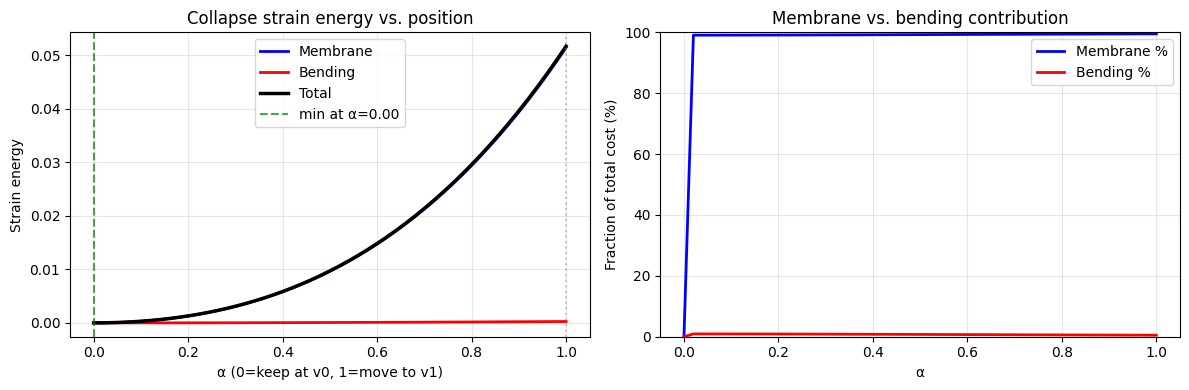

Optimal alpha: 0.000
  At alpha=0 (stay at v0): total=1.321676e-36
  At alpha=0.5 (midpoint): total=9.715151e-03
  At alpha=1 (move to v1): total=5.171967e-02
  At optimal:              total=1.321676e-36


In [12]:
def collapse_strain_energy(verts_orig, faces_arr, u, v, alpha, E_y, nu_val, thick):
    """Total collapse strain energy for edge (u,v) at alpha."""
    p_w = (1 - alpha) * verts_orig[u] + alpha * verts_orig[v]
    verts_new = verts_orig.copy()
    verts_new[u] = p_w
    
    D_mat = (E_y / (1 - nu_val**2)) * np.array([
        [1, nu_val, 0], [nu_val, 1, 0], [0, 0, (1 - nu_val) / 2]])
    kb_val = E_y * thick**3 / (12.0 * (1.0 - nu_val**2))
    
    # Find shared and surviving faces
    adj_local = MeshAdjacency(TriMesh(vertices=verts_orig, faces=faces_arr))
    edge_key = (min(u, v), max(u, v))
    shared_faces = adj_local.edge_faces.get(edge_key, set())
    
    # Membrane energy on surviving faces that touch u
    U_membrane = 0.0
    surviving = []
    for fi in adj_local.vert_faces[u]:
        if fi in shared_faces:
            continue
        surviving.append(fi)
        i0, i1, i2 = int(faces_arr[fi, 0]), int(faces_arr[fi, 1]), int(faces_arr[fi, 2])
        e, _ = triangle_membrane_energy(
            verts_orig[i0], verts_orig[i1], verts_orig[i2],
            verts_new[i0], verts_new[i1], verts_new[i2])
        U_membrane += e
    
    # Bending energy on surviving interior edges involving u
    U_bending = 0.0
    for fi in surviving:
        face_verts = [int(faces_arr[fi, k]) for k in range(3)]
        for k in range(3):
            ea = face_verts[(k+1) % 3]
            eb = face_verts[(k+2) % 3]
            ekey = (min(ea, eb), max(ea, eb))
            partner_faces = adj_local.edge_faces.get(ekey, set())
            if len(partner_faces) != 2:
                continue
            # Only count if this edge involves the collapse site
            if u not in (ea, eb):
                continue
            fi2 = (partner_faces - {fi}).pop()
            if fi2 in shared_faces:
                continue
            face2_verts = set(int(faces_arr[fi2, k]) for k in range(3))
            opp_a = (set(face_verts) - {ea, eb}).pop()
            opp_b = (face2_verts - {ea, eb}).pop()
            
            theta_rest = compute_dihedral_angle(
                verts_orig[ea], verts_orig[eb], verts_orig[opp_a], verts_orig[opp_b])
            theta_new = compute_dihedral_angle(
                verts_new[ea], verts_new[eb], verts_new[opp_a], verts_new[opp_b])
            
            e_length = np.linalg.norm(verts_new[ea] - verts_new[eb])
            a0 = triangle_area(verts_new[ea], verts_new[eb], verts_new[opp_a])
            a1 = triangle_area(verts_new[ea], verts_new[eb], verts_new[opp_b])
            if a0 + a1 > 1e-16:
                U_bending += kb_val * e_length**2 / (a0 + a1) * (theta_new - theta_rest)**2
    
    return U_membrane, U_bending, U_membrane + U_bending


alphas = np.linspace(0, 1, 51)
energies_m = []
energies_b = []
energies_t = []

for a in alphas:
    um, ub, ut = collapse_strain_energy(vertices, faces, 0, 1, a, E_young, nu, thickness)
    energies_m.append(um)
    energies_b.append(ub)
    energies_t.append(ut)

energies_m = np.array(energies_m)
energies_b = np.array(energies_b)
energies_t = np.array(energies_t)

best_idx = np.argmin(energies_t)
best_alpha = alphas[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(alphas, energies_m, 'b-', linewidth=2, label='Membrane')
ax.plot(alphas, energies_b, 'r-', linewidth=2, label='Bending')
ax.plot(alphas, energies_t, 'k-', linewidth=2.5, label='Total')
ax.axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'min at α={best_alpha:.2f}')
ax.axvline(0.0, color='gray', linestyle=':', alpha=0.4)
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('α (0=keep at v0, 1=move to v1)')
ax.set_ylabel('Strain energy')
ax.set_title('Collapse strain energy vs. position')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(alphas, energies_m / (energies_t + 1e-30) * 100, 'b-', linewidth=2, label='Membrane %')
ax.plot(alphas, energies_b / (energies_t + 1e-30) * 100, 'r-', linewidth=2, label='Bending %')
ax.set_xlabel('α')
ax.set_ylabel('Fraction of total cost (%)')
ax.set_title('Membrane vs. bending contribution')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"Optimal alpha: {best_alpha:.3f}")
print(f"  At alpha=0 (stay at v0): total={energies_t[0]:.6e}")
print(f"  At alpha=0.5 (midpoint): total={energies_t[25]:.6e}")
print(f"  At alpha=1 (move to v1): total={energies_t[-1]:.6e}")
print(f"  At optimal:              total={energies_t[best_idx]:.6e}")

## 8. Compare All Edges

Now let's compute the collapse strain energy for every edge in the tent mesh.
The greedy simplifier would collapse the edge with **lowest** total cost first.

In [13]:
print(f"{'Edge':<10s} {'Best α':>8s} {'Membrane':>12s} {'Bending':>12s} {'Total':>12s}")
print(f"{'-'*10} {'-'*8} {'-'*12} {'-'*12} {'-'*12}")

edge_costs = []
for u, v in edges:
    # Find best alpha
    best_cost = float('inf')
    best_a = 0.5
    for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
        _, _, total = collapse_strain_energy(vertices, faces, u, v, a, E_young, nu, thickness)
        if total < best_cost:
            best_cost = total
            best_a = a
    um, ub, ut = collapse_strain_energy(vertices, faces, u, v, best_a, E_young, nu, thickness)
    edge_costs.append((u, v, best_a, um, ub, ut))
    print(f"  ({u},{v})     {best_a:8.2f} {um:12.4e} {ub:12.4e} {ut:12.4e}")

# Sort by total cost
edge_costs.sort(key=lambda x: x[5])
print(f"\nCollapse priority (cheapest first):")
for i, (u, v, a, um, ub, ut) in enumerate(edge_costs):
    print(f"  {i+1}. edge ({u},{v}) at α={a:.2f} — cost={ut:.4e}")

Edge         Best α     Membrane      Bending        Total
---------- -------- ------------ ------------ ------------
  (0,1)         0.00   1.3217e-36   0.0000e+00   1.3217e-36
  (0,2)         0.00   1.3217e-36   0.0000e+00   1.3217e-36
  (0,3)         0.00   1.3217e-36   0.0000e+00   1.3217e-36
  (0,4)         0.00   1.3217e-36   0.0000e+00   1.3217e-36
  (1,2)         0.00   6.6084e-37   0.0000e+00   6.6084e-37
  (1,4)         0.00   6.6084e-37   0.0000e+00   6.6084e-37
  (2,3)         0.00   6.6084e-37   0.0000e+00   6.6084e-37
  (3,4)         0.00   6.6084e-37   0.0000e+00   6.6084e-37

Collapse priority (cheapest first):
  1. edge (1,2) at α=0.00 — cost=6.6084e-37
  2. edge (1,4) at α=0.00 — cost=6.6084e-37
  3. edge (2,3) at α=0.00 — cost=6.6084e-37
  4. edge (3,4) at α=0.00 — cost=6.6084e-37
  5. edge (0,1) at α=0.00 — cost=1.3217e-36
  6. edge (0,2) at α=0.00 — cost=1.3217e-36
  7. edge (0,3) at α=0.00 — cost=1.3217e-36
  8. edge (0,4) at α=0.00 — cost=1.3217e-36


## 9. Is the Cost Quadratic in Position?

For the strain energy to give us a clean "stiffness quadric" (like QEM), it needs to be
approximately quadratic in p_w. Let's check by fitting a quadratic to the energy curve
and measuring the residual.

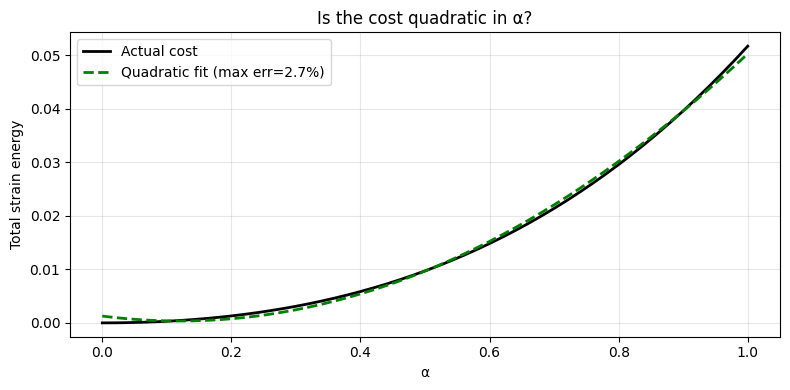

Quadratic fit: 6.442134e-02 α² + -1.539032e-02 α + 1.271764e-03
Max absolute residual: 1.416886e-03
Relative error: 2.7395%

The cost is well-approximated by a quadratic in α.
This means a 1D quadratic fit (sample at 0, 0.5, 1) finds the optimum accurately.


In [14]:
# Fit quadratic to the total energy vs alpha curve
coeffs = np.polyfit(alphas, energies_t, 2)
quadratic_fit = np.polyval(coeffs, alphas)
residual = np.max(np.abs(energies_t - quadratic_fit))
relative_error = residual / (np.max(energies_t) - np.min(energies_t) + 1e-30)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(alphas, energies_t, 'k-', linewidth=2, label='Actual cost')
ax.plot(alphas, quadratic_fit, 'g--', linewidth=2, label=f'Quadratic fit (max err={relative_error:.1%})')
ax.set_xlabel('α')
ax.set_ylabel('Total strain energy')
ax.set_title('Is the cost quadratic in α?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Quadratic fit: {coeffs[0]:.6e} α² + {coeffs[1]:.6e} α + {coeffs[2]:.6e}")
print(f"Max absolute residual: {residual:.6e}")
print(f"Relative error: {relative_error:.4%}")
print()
if relative_error < 0.05:
    print("The cost is well-approximated by a quadratic in α.")
    print("This means a 1D quadratic fit (sample at 0, 0.5, 1) finds the optimum accurately.")
else:
    print("The cost deviates from quadratic — need finer sampling or direct minimization.")
    print("(Expected: Green-Lagrange strain is quadratic in displacement, so")
    print(" the energy is quartic. But for small strains, quadratic dominates.)")

## 10. Summary

### The Collapse Strain Energy Cost

$$\text{Cost}(u, v, \alpha) = \underbrace{\sum_{t} \frac{A_t \cdot h}{2} \varepsilon_t^T D \varepsilon_t}_{\text{membrane: metric distortion}} + \underbrace{\sum_{e} k_b \frac{|e|^2}{A_0 + A_1} (\theta'_e - \theta_e)^2}_{\text{bending: curvature distortion}}$$

### Properties:

| Property | How it works |
|----------|-------------|
| **Geometry-aware** | Strain penalizes edge length changes; bending penalizes crease changes |
| **Material-weighted** | Stiff regions cost more to distort (controlled by E, h) |
| **Position-dependent** | Cost varies with α → can find optimal vertex placement |
| **Approximately quadratic** | 1D fit works for optimal α (or full 3D quadric for off-edge placement) |
| **Curvature-preserving** | Bending term organically preserves creases without needing line quadrics |
| **Zero at rest** | Before any collapse, cost = 0 (original mesh is the rest state) |

### vs. QEM:
- QEM measures distance to tangent planes (geometric, material-independent)
- Collapse strain energy measures deformation from original shape (geometric + material)
- Both are ≈ quadratic in vertex position → same SVD solve for optimal placement

### vs. Schur mismatch (||K'-K*||²):
- Schur mismatch measures change in the *stiffness operator* (abstract)
- Strain energy measures *actual geometric distortion* weighted by stiffness (concrete)
- Strain energy naturally prevents vertex drift (edge length changes cost energy)

### Next step:
Implement this as a simplification cost in `src/kms/simplify_strain.py` and compare
against QEM and Schur flow on real meshes.